# European Commission

In [19]:
import joblib
import xgi
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from metrics import evolution_nb_nodes, degrees_t, gini

## Size of the Network

Fraction of new nodes per meeting: 0.039766098666234775


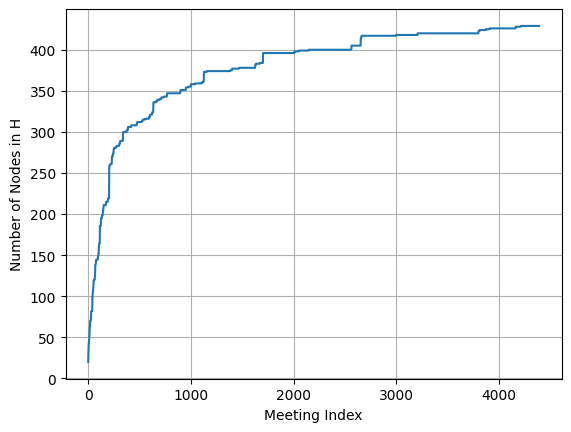

In [40]:

freq = 1
edges_emp = joblib.load('../data/edges_village.joblib')
H_emp = xgi.Hypergraph(edges_emp)
edges_emp = [list(e) for e in H_emp.edges.members()]
np.random.shuffle(edges_emp)

N_t_emp = evolution_nb_nodes(edges_emp, freq)

plt.plot(range( 0, len(N_t_emp)*freq, freq), N_t_emp)
plt.xlabel("Meeting Index")
plt.ylabel("Number of Nodes in H")
plt.grid()

fraction_new_nodes =np.polyfit( range(  len(N_t_emp)), N_t_emp, deg = 1)[0]

print(f'Fraction of new nodes per meeting: {fraction_new_nodes}')

## Number (or fraction) of New Entities Per Meeting

In [ ]:
node_t = set()
p_new =[]
for e in edges_emp:
    new_nodes = set(e) - nodes_t
    p_new.append(len(new_nodes)/len(e))
    nodes_t |= new_nodes

0.012061496095196396


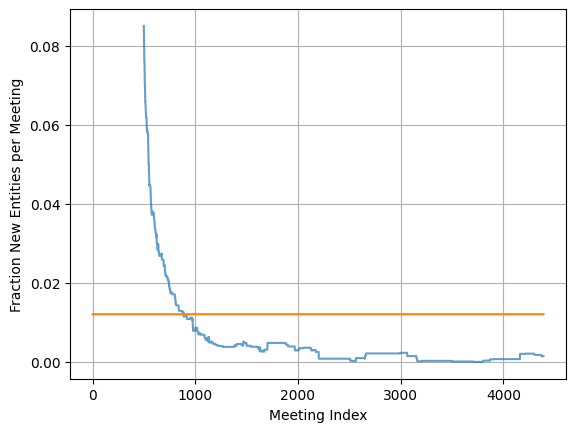

In [ ]:
nodes_t = set()
N_new = []

for meeting in edges_emp:
    new_entities = set(meeting) - nodes_t
    N_new.append(len(new_entities)/len(meeting))
    nodes_t |= new_entities

window_size = 500  # Adjust the window size as needed
N_new_smoothed = pd.Series(N_new).rolling(window=window_size).mean()

plt.plot(range(len(N_new_smoothed)), N_new_smoothed, alpha=0.7)
plt.plot(range(len(N_new)), [np.mean(N_new)]*(len(N_new)))
plt.xlabel("Meeting Index")
plt.ylabel("Fraction New Entities per Meeting")
plt.grid()
print(np.mean(N_new))

## Node exiting the network

In [ ]:
df = EC.meetings[['Date', 'TR ID']].explode('TR ID')
result = df.groupby('TR ID')['Date'].agg(Start_Index=lambda x: x.idxmin(), End_Index=lambda x: x.idxmax())
result['life_time'] = result['End_Index'] - result['Start_Index']
result['degree'] = df.groupby('TR ID')['TR ID'].count()

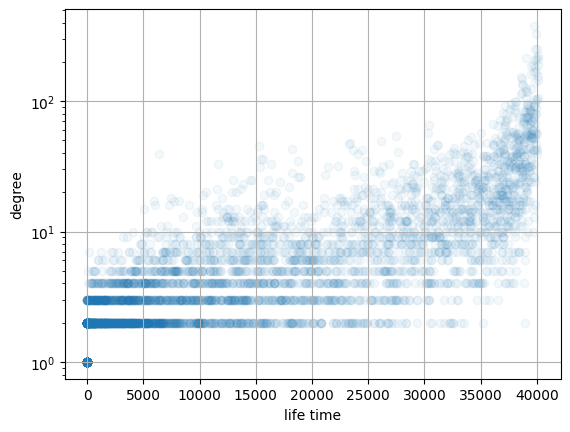

In [ ]:
plt.scatter(result['life_time'], result['degree'], alpha = 0.05)
plt.xlabel('life time')
plt.ylabel('degree')
plt.yscale('log')
plt.grid()

In [ ]:
for k in range(2,19):
    sns.kdeplot(result[result['degree'].isin([k]) ]['life_time'], alpha = 1, label = k, cut = 0)

plt.legend()
plt.show()
sns.kdeplot(result['life_time'], alpha = 1, label = k, cut = 0)



In [ ]:
import scipy.special
def Prob_T_i_cond_k_i(n, k_i, N ):
    return scipy.special.comb(n-1, k_i-2)* (1/N)**(k_i-2)*(1-1/N)**(n-k_i+1)*1/N
def Prob_T_i(n,N):
    for k_i in range(2,n+1):
        Prob_T_i_cond_k_i(n, k_i, N )
    

for k_i in range(2,18):
    t = np.arange(0,100000,100)
    N = len(EC.get_orga())
    y = [Prob_T_i_cond_k_i(tau, k_i, 1000) for tau in t]
    fig, ax = plt.subplots(figsize =(4,4))
    ax.plot(t, y, label = 'rand')
    sns.kdeplot(result[result['degree'].isin([k_i]) ]['life_time'], alpha = 1,label = 'emp', ax = ax, cut = 0)
    ax.legend()
    plt.title(f'k = {k_i}')
    plt.show()

## Evolution of Meeting Size

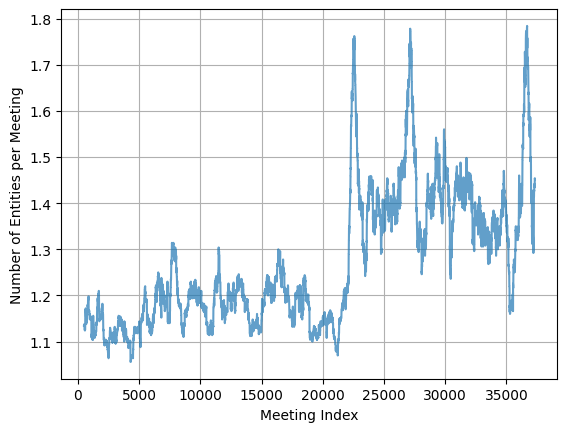

In [ ]:
meeting_size_t=[len(meeting) for meeting in hyperedges_emp]

window_size = 500  # Adjust the window size as needed
size_smoothed = pd.Series(meeting_size_t).rolling(window=window_size).mean()
plt.plot(range(len(size_smoothed)), size_smoothed, alpha=0.7)
plt.xlabel("Meeting Index")
plt.ylabel("Number of Entities per Meeting")
plt.grid()

## Evolution of the Gini index


In [ ]:
freq = 1000
hyperedges_emp = list(EC.meetings['TR ID'].apply(list))
degrees =degrees_t(hyperedges_emp, freq)
gini_list_emp = [gini(element) for element in degrees]


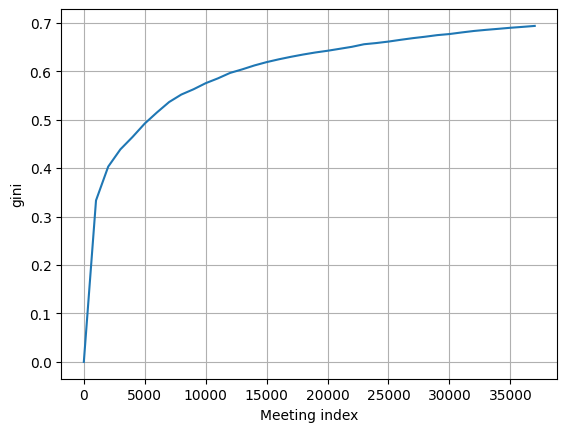

In [ ]:
plt.plot( range(0, len(gini_list_emp)*freq,freq), gini_list_emp)
plt.xlabel('Meeting index')
plt.ylabel('gini')
plt.grid()
plt.savefig('./out/Figures/gini_emp.pdf')

### Category of registration vs edge size

In [ ]:
def edge_size_statistics(H, df_nodes):
    degree =dict(H.degree())
    size = dict(H.size())
    bipartite = xgi.to_bipartite_edgelist(H)
    bipartite = pd.DataFrame(bipartite, columns = ['Nodes', 'Edges'])
    bipartite['degree'] = bipartite['Nodes'].map(degree)
    bipartite['size'] = bipartite['Edges'].map(size)
    bipartite['cat'] = bipartite['Nodes'].apply(lambda x: df_nodes.loc[x, 'Category of registration'])
    bipartite['members fte'] = bipartite['Nodes'].apply(lambda x: EC.entities.loc[x]['Members FTE'])

    return bipartite

In [73]:
bipartite_df =  edge_size_statistics(EC.sub_hypergraph(), EC.entities)

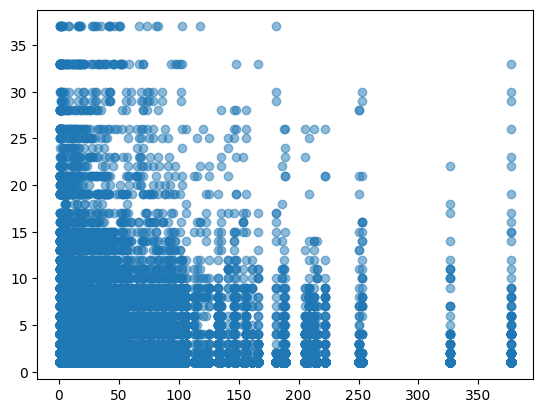

In [75]:
plt.scatter(bipartite_df['degree'],bipartite_df['size'] , alpha = 0.5)

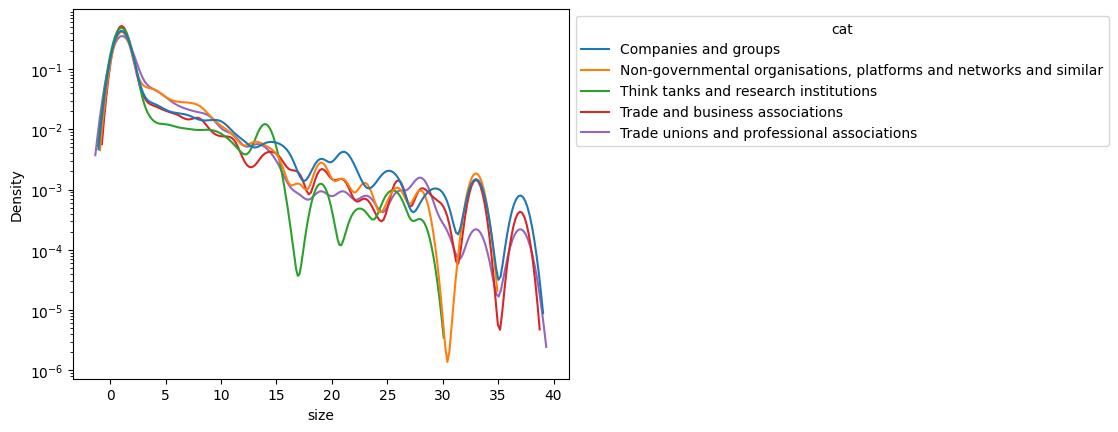

In [27]:
import seaborn as sns
categories = bipartite['cat'].dropna().unique()[:5]
bipartite = bipartite[bipartite['cat'].isin(categories) ]
fig, ax = plt.subplots()
#sns.histplot(bipartite, x = 'Edges', hue = 'Nodes', stat = 'density', binwidth = 1, kde = 'True')
sns.kdeplot(bipartite, x = 'size', hue = 'cat', ax = ax, common_norm = False, log_scale = (False, True))

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))


In [28]:
# What are the meetings that gather a large number of organization? 
EC.meetings['Size'] = EC.meetings['TR ID'].apply(len)
EC.meetings['orga type']  = EC.meetings['TR ID'].apply(lambda x : Counter([ EC.entities.loc[orga]['Category of registration'] for orga in x]))
# save csv file
EC.meetings.sort_values(by = 'Size', ascending = False)[['Size', 'Subject' , 'Relative commission', 'orga type', 'Name of interest representative']].iloc[:500].to_csv('./out/large_meetings.csv')

### Members FTE 

In [ ]:

bipartite['members fte'] = bipartite['Nodes'].apply(lambda x: EC.entities.loc[x]['Members FTE'])


Text(0.5, 0, 'Members FTE')

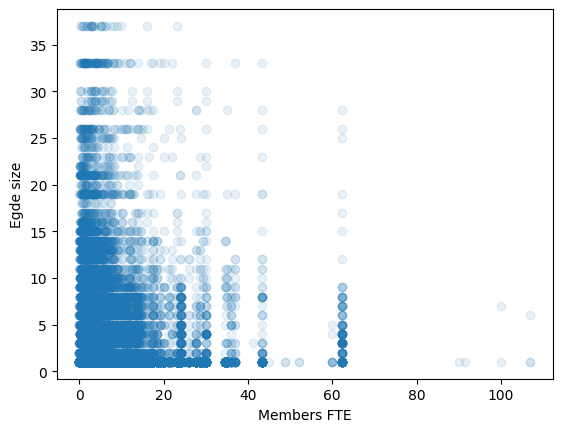

In [37]:
plt.scatter(bipartite['members fte'], bipartite['size'], alpha = 0.1)
plt.ylabel('Egde size')
plt.xlabel('Members FTE')

### Level of interest

In [ ]:
bipartite = xgi.to_bipartite_edgelist(EC.sub_hypergraph())
bipartite = pd.DataFrame(bipartite, columns = ['Nodes', 'Edges'])
levels = split_column(EC.entities, 'Level of interest', prefix = 'Level')
bipartite['Level'] = bipartite['Nodes'].apply(lambda x: levels.loc[x]['Level European'])
bipartite['Edges'] = bipartite['Edges'].apply(lambda x: len(EC.meetings.loc[x]['TR ID']))

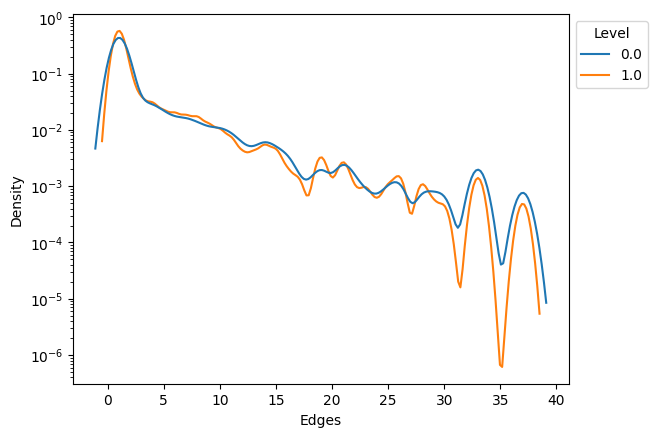

In [ ]:
import seaborn as sns
fig, ax = plt.subplots()
#sns.histplot(bipartite, x = 'Edges', hue = 'Nodes', stat = 'density', binwidth = 1, kde = 'True')
sns.kdeplot(bipartite, x = 'Edges', hue = 'Level', ax = ax, common_norm = False, log_scale = (False, True))

sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

## Probability of edge at time $t$ knowing that e'

In [ ]:
edges_2 = [edge for edge in hyperedges_emp if len(edge)>1]
intersection_profile = []
for i, edge in enumerate(edges_2):
    for previsous_edge in edges_2[:i]:
        intersection_size = len(set(edge) & set (previsous_edge)) / len(set(edge) | set (previsous_edge))
        intersection_profile.append(intersection_size) 



In [ ]:
k = 4
l = 4
intersection_profile = []
edges_k = [edge for edge in hyperedges_emp if len(edge)==k]
edges_l = [edge for edge in hyperedges_emp if len(edge)==l]
r_kl = { j: 0 for j in range(max(k,l)+1)}

for i, edge in enumerate(edges_k):
    for previsous_edge in edges_l[:i]:
        j = len(set(edge) & set (previsous_edge)) 
        r_kl[j] +=  1        

In [ ]:
from collections import Counter
from tqdm import tqdm
# List of hyperedges ordered by time
hyperedges = [e for e in hyperedges_emp if len(e)>2]

# Initialize counters
observed_count = Counter()
condition_count = Counter()
baseline_probabilities = Counter()

t_init = 1
# Iterate through time steps
for t in tqdm(range(t_init, len(hyperedges))):
    H_t = hyperedges[:t] # Current state of the hypergraph
    current_edge = hyperedges[t]  # Edge at time t
    
    # Condition checks
    exact_match = current_edge in H_t
    subset_match = any( len(set(current_edge) & (set(e))) ==7 for e in H)
    superset_match = any(set(e).issubset(set(current_edge)) for e in H)
    
    # Update counts based on conditions
    if subset_match :
        condition_count[tuple(current_edge)] += 1
        observed_count[tuple(current_edge)] += 1

    else:
        condition_count[tuple(current_edge)] += 1
    
    baseline_probabilities[tuple(current_edge)] = Counter((tuple(e) for e in H_t))[tuple(current_edge)] / len(H_t) 

# Compute probabilities
probabilities = {e: observed_count[e] / condition_count[e] for e in observed_count}

# # Compare with baseline probability
# baseline_probabilities = Counter((tuple(e) for e in hyperedges))
# baseline_probabilities = {e: count / len(hyperedges) for e, count in baseline_probabilities.items()}

# Print probabilities
print("Conditional probabilities:", probabilities)
print("Baseline probabilities:", baseline_probabilities)


100%|██████████| 1727/1727 [00:05<00:00, 325.33it/s]

Conditional probabilities: {('85686156700-13', '16549972091-86', '394013515467-95', '09854512780-89', '11977456675-84', '85083981189-35', '57868523887-16', '11063928073-34', '8557515321-37'): 1.0, ('46834536998-79', '96645517357-19', '95261732139-73', '1414929419-24', '47937943241-80', '9832909575-41', '1083162721-43'): 0.6666666666666666, ('61650796093-48', '62722978644-95', '726584717191-62', '72279144480-58', '717101617809-28', '93038071152-83', '79465004946-12', '19153965510-75', '9224280267-20'): 1.0, ('43167137250-27', '85172105610-37', '15987896534-82', '25487567824-45', '4722660838-23', '501468815548-71', '75039383277-48', '39300567160-02', '3978240953-79', '08957111909-85', '54437813115-56', '64270747023-20', '867433111414-11', '55820581197-35'): 1.0, ('06798511314-27', '1414929419-24', '9825553393-31', '58744833263-19', '00723343929-96', '9832909575-41', '55888811123-49', '1083162721-43'): 1.0, ('43167137250-27', '15987896534-82', '25487567824-45', '84973761187-60', '52657805

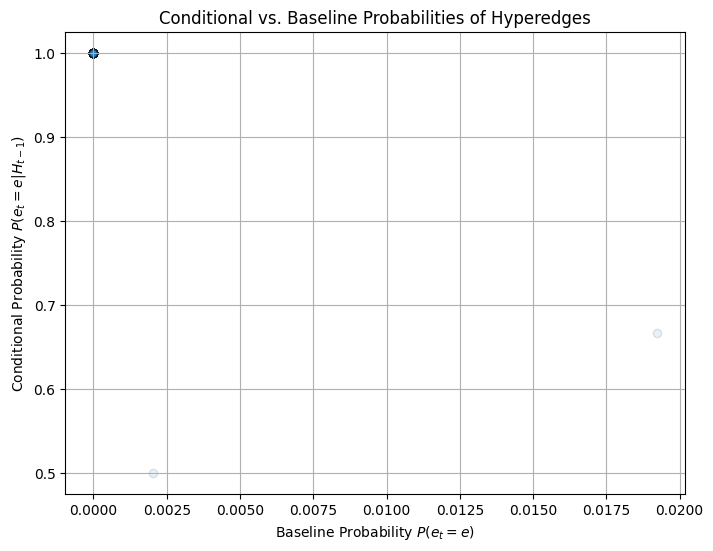

In [ ]:
import matplotlib.pyplot as plt

common_edges = probabilities.keys()

# Extract probabilities for plotting
x = [baseline_probabilities[e] for e in common_edges]
y = [probabilities[e] for e in common_edges]

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.1, edgecolors='k')
plt.title("Conditional vs. Baseline Probabilities of Hyperedges")
plt.xlabel("Baseline Probability $P(e_t = e)$")
plt.ylabel("Conditional Probability $P(e_t = e | H_{t-1})$")
plt.grid()
plt.show()


Probalility of $e$ at time $t$ knowing that multiplicity of $t-1$ is $\mu_e^{t-1}=k$ 

$P(e^t | \mu_e^{t-1}=k)$

Is this a conditional probablity or are these two events independent?


In [ ]:
Counter(tuple(edge) for edge in hyperedges_emp[:5])[('jfhdv')]

0

In [ ]:

def degrees_t(hyperedges, freq):
    degrees = []
    for i in range(1,len(hyperedges) , freq):
        degree_t = Counter(chain.from_iterable(hyperedges[:i]))
        degrees.append(np.array(list(degree_t.values())))
    return degrees
    
def gini(x):
    total = 0
    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))
    return total / (len(x)**2 * np.mean(x))

def evolution_nb_nodes(hyperedges: list, freq:int):
    n_t = [] # number of nodes at time t
    nodes_t = set() # set of nodes at time t
    for i in range(0, len(hyperedges), freq):
        batch_ids = set(np.concatenate(hyperedges[i:i+freq]))
        nodes_t |= batch_ids  
        n_t.append(len(nodes_t))
    return(n_t)